In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from python_utils.visualization_utils import create_summary_table, plot_snr_performance

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# 10 by 5 Mixing Results

In [3]:
df_predictiveBSS = pd.read_pickle(r"../Results/predictive_bss_noisy_nnsparse_10by5_results.pkl")
df_predictiveBSS.tail()

,Model,seed,SINR,SNR,SNRinp,execution_time
535,CorInfoMax,2801,6.620638,"[[4.702304531094659, 6.956891333216879, 6.5411...",5.0,7.667873
536,LDMIBSS,2801,7.420517,"[[5.873330320330332, 7.943820581082985, 6.9475...",5.0,26.895249
537,PredictiveDecorrBSS,2901,7.923702,"[[6.659313501572555, 8.228449349108608, 10.417...",5.0,8.609424
538,CorInfoMax,2901,7.194168,"[[5.968832884887762, 7.538183653427496, 9.7803...",5.0,7.892794
539,LDMIBSS,2901,7.571547,"[[6.381458790935705, 7.847317805884906, 9.9673...",5.0,27.184849


In [4]:
df_upem = pd.read_pickle(r"../Results/upem_noisy_nnsparse_10by5_results.pkl")
def interleave(A, B,k):
    nA, nB = len(A), len(B)

    # Group index for A (every k rows = one group)
    groups_A = np.arange(nA) // k

    # Position within each group (A rows come first)
    pos_A = np.arange(nA) % k

    # Build DataFrame with ordering keys
    A_ = A.copy()
    A_['_grp'] = groups_A
    A_['_pos'] = pos_A
    A_['_src'] = 0  # A comes before B within group

    # For B: one row per group
    B_ = B.iloc[:groups_A.max() + 1].copy()
    B_['_grp'] = np.arange(len(B_))
    B_['_pos'] = k   # comes after the 5 A rows
    B_['_src'] = 1

    # Combine and sort once
    out = pd.concat([A_, B_], ignore_index=True)
    out = out.sort_values(['_grp', '_pos', '_src'])

    return out.drop(columns=['_grp', '_pos', '_src']).reset_index(drop=True)
df_combined = interleave(df_predictiveBSS, df_upem,3)

In [5]:
summary_df = create_summary_table(df_combined)
summary_df

,,SINR (dB),mSNR (dB),Time (s)
Model,SNRinp,,,
CorInfoMax,5.0,6.07 ± 0.22,6.29 ± 0.17,8.01 ± 0.12
LDMIBSS,5.0,6.53 ± 0.26,6.76 ± 0.21,26.96 ± 0.03
PredictiveDecorrBSS,5.0,6.80 ± 0.28,7.05 ± 0.22,8.84 ± 0.22
PredictiveDecorrBSSSimple,5.0,6.57 ± 0.45,6.96 ± 0.23,2.95 ± 0.06
CorInfoMax,10.0,10.03 ± 0.40,10.37 ± 0.33,8.99 ± 0.29
LDMIBSS,10.0,10.13 ± 0.48,10.52 ± 0.38,27.38 ± 0.61
PredictiveDecorrBSS,10.0,10.85 ± 0.42,11.19 ± 0.34,9.31 ± 0.48
PredictiveDecorrBSSSimple,10.0,10.13 ± 0.85,10.83 ± 0.43,3.15 ± 0.02
CorInfoMax,15.0,14.86 ± 0.55,15.29 ± 0.45,9.68 ± 0.19


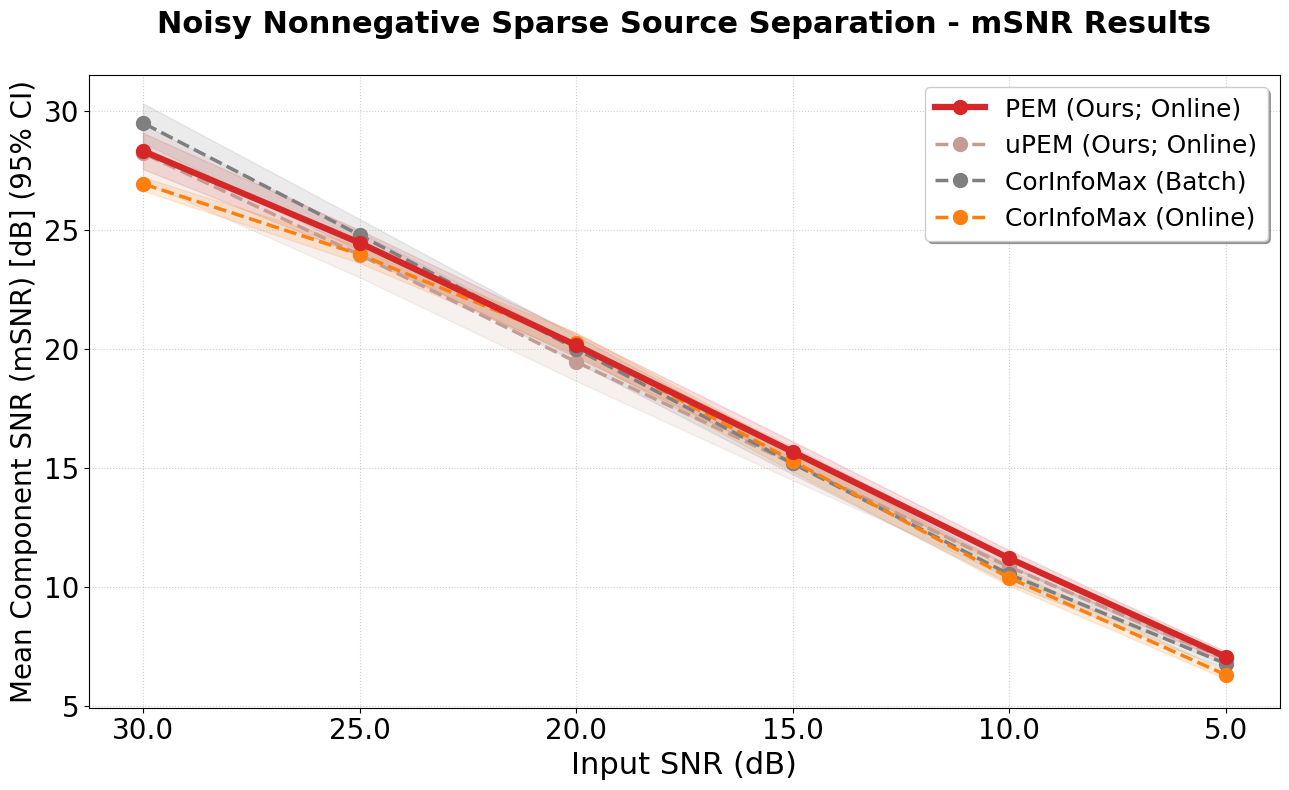

In [6]:
plot_title = "Noisy Nonnegative Sparse Source Separation - mSNR Results"
bss_plot = plot_snr_performance(summary_df, 'SNRinp', title = plot_title)
plt.savefig('Figures/NNSparse_Noisy_Comparison.pdf', format='pdf', bbox_inches = 'tight')
bss_plot.show()